<a href="https://colab.research.google.com/github/killerfrost22/killerfrost22.github.io/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Energy Crisis Texas 2021 Case Study**

### **Authors: Yizhan Ao, Youhan Dou，Haiwei Sun**

# **1. Background and motivation**

  On February 13-17 2021, a major winter and ice storm, also known as Winter Storm Uri,  had widespread impacts across the United States. (Axelrod) The winter storm resulted in a massive electricity failure across the state of Texas and left millions of homes and businesses without power. (Axelrod) In our research, we are seeking answers to how the land of fertile power Texas reached statewide power blackouts. By investigating the role of the Electric Reliability Council of Texas (ERCOT), we are trace-examining historical natural hazards in Texas to better understand what can be improved.

Using data pulled from ERCOT Website and peer-reviewed articles will help us better understanding the natural hazards, and the functionality of ERCOT, furthermore the transitions in Texas from Fossil fuel to greener energy. By doing such research we want to find out who should be led responsible for the power failure of this incident and why the 2021 Texas Power Crisis is a warning sign for the rest of the US power grid. The intended publishing place is at Diamondback, an independent student newspaper associated with the University of Maryland, discussing the Texas 2021 power crisis. The audience will be journalists, readers, and researchers furthermore people who are reviewing the power crisis incident.

# **2. Understanding and generalization of our project**


In this Project, solutions to our problems are straightforward: 
1. Identify the problem.
2. Find reasons behind the problem.
3. Solve the problem, if possible.


# **3. Resources and Implementation**


We have used energy generation data pulled from the ERCOT archive published right after the winter storm incident. Using python libraries including geopanda, altair, sklearn and shapely to better visualize data. Using data analysis tools from statistics classes, We have tested the confidence level of my theory. Using national archive and U.S. energy information administration aftermath review to cross-examine the liability and accuracy of our data-driven conclusion to the questions above.

### **Where is the data from: **
1. For power grid load and generation from the year 2021: 
http://www.ercot.com/content/wcm/lists/181766/IntGenbyFuel2021.xlsx
2. For power grid load and generation from the year 2007 to 2020:
http://www.ercot.com/content/wcm/lists/181766/FuelMixReport_PreviousYears.zip
2. For temperature of Texas Austin 2020-2021: 
https://www.meteoblue.com/en/weather/archive/export/austin_united-states-of-america_4671654


**How we conducted the process:**
1. Make sure the data files are in the same folder as your ipynb file
2. In your python script import your data files are libraries
3. Programming;)
4. Analyising the statistics and graphs
5. Compared to the data review afterwards to test our reliability

# **4. The body**

A thought on the 


On Feb. 16th,  Greg Abbott, governor of Texas, directed the statewide power system failure towards frozen wind turbines.  
`“Our wind and our solar got shut down, and they were collectively more than 10 percent of our power grid, and that thrust Texas into a situation where it was lacking power on a statewide basis. ... It just shows that fossil fuel is necessary” (ABC News)`

The governor is not the only one who blames the energy failure on the greener energy. Rep. Dan Crenshaw (R-Tex.) shared similar blaming tweets of the way how the state’s grid failed, stating that fossil fuel and nuclear strength played — however extensively utilized the instant to assault wind power on Tuesday.(ABC News)

There are more examples online blaming greener energy on this issue ever since the start of the power blackouts. However the official team of the governor rejects his own claim towards the issue. All of these different claims made us think: Why is everyone telling a different story but people cannot conclude the reason solidifying the power grid keeps failing? Are the greener power generators that are unreliable towards an emergency breakdown? Are those comments trustworthy when they are coming from the politician instead of the managers or researchers who are in the industry? We have decided to find out the truth by myself among all of the words from the media and politicians.


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")
plt.style.use("ggplot")

Using a data frame structure we are trying to figure out what happened exactly during the time of 2021 winter crisis when the winter storm hit hardest time on Feb 10-13 and Feb 13-17

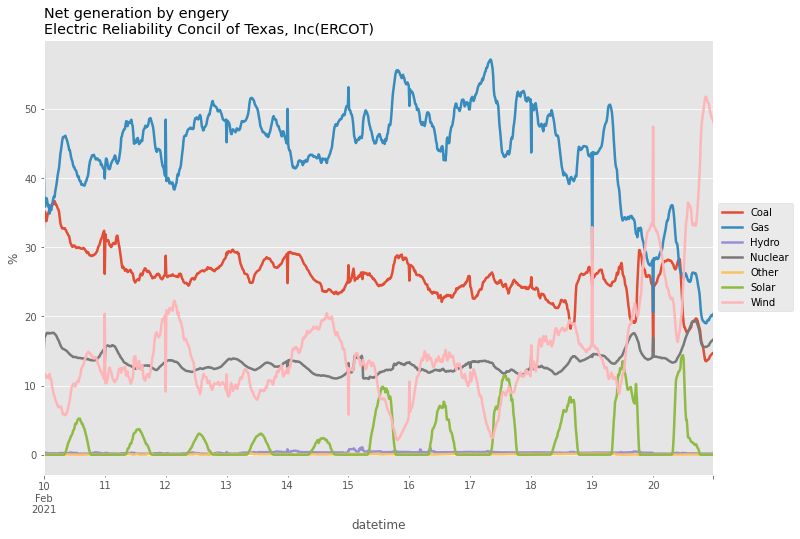

In [ ]:
ercot_df = pd.read_excel("IntGenbyFuel2021.xlsx", sheet_name='Feb')
ercot_df = ercot_df.replace({
    'Gas-CC' : 'Gas',
    "Biomass": "Other"
})
ercot_df['Date'] = ercot_df['Date'].astype(str)
ercot_df = ercot_df[ercot_df.Date >= '2021-02-10']
ercot_df = ercot_df[ercot_df.Date <= '2021-02-20']
ercot_df['Date'] = ercot_df['Date'].astype(str)
ercot_df = (ercot_df.drop(columns=['Total'])
            .set_index(['Date','Fuel','Settlement Type'])
            .stack()
            .reset_index()
            .rename(columns={'level_3':'hour',0:'power'})
           )
ercot_df['datetime'] = pd.to_datetime(ercot_df['Date'] + ' ' + ercot_df['hour']).dt.tz_localize('America/Chicago')
ercot_df = ercot_df.drop(columns=['Date','hour','Settlement Type'])
ercot_df = ercot_df.pivot_table(index='datetime', columns='Fuel', values = ['power'])
ercot_df.columns = [i[1] for i in ercot_df.columns]
q1_plot = ercot_df.copy()
q1_plot = q1_plot.div(q1_plot.sum(axis=1), axis=0) * 100
q1_plot.plot(figsize = (12, 8), alpha = 5, lw = 2.5)
plt.title("Net generation by engery \nElectric Reliability Concil of Texas, Inc(ERCOT)",
         loc='left')
L = plt.ylabel('%')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.savefig("p1.png", dpi = 800)
plt.show()

According to ERCOT energy generated by the fuel of the year 2020, we saw an estimation that Gas-CC(combined cycle) took 40% of the total generated power. The wind takes 23% of the total. Coal is 18%. Nuclear is 11%. Gas is 6%. Solar is 2%.  Others are rounded to 0%. All adds up to 100%. (Note: The numbers are estimation) 


We see a general trend of stable generation of nuclear that is around 15% during the extended length of Feb. 10th to 21st. Solar fluctuated from 0-10% which is understandable since there is no sunlight during the night. Solar has relatively low generation when the winter storm struck (Feb. 11-15). We saw a trend of a decreased coal power generation portion along with the timeline. The wind was struck on Feb 15 according to the graph, this is reasonable since wind turbines indeed are frozen for a while according to the report(ABC News). However, if we take a close eye on power generation by losses, we can tell the total generation is still stable, as more power generated by Gas-CC according to the power generation by Megawatt-Hours (ERCOT). When the wind power starts to collapse, the gas immediately takes up the portion lost by the wind(See figure 1) . This immediate loss of wind power is around 20,000 units. The power compensated by gas when the wind starts to fail is around 25,000 units. Governor Greg Abbott indeed made a point on wind power production loss. However, blaming the systematic failure of the whole power grid on wind power is not proper in this specific scenario. Wind fail is not the only part of the whole story.


Draw the relationship between weather and electricity consumption

In [ ]:
folder = "FuelMixReport_PreviousYears/"
import re
res_lists = []
res_lists2 = []
for i in os.listdir(folder):
    f = folder + i
    print(f)
    
    yr = re.findall('[0-9]+', i)[0]
    yr = int(yr)
    
    if yr <= 2016:
        sheets_dict = pd.read_excel(f, sheet_name=None)

        full_table = pd.DataFrame()
        for name, sheet in sheets_dict.items():
            if sheet.shape[1] > 20 & sheet[sheet.columns[0]].astype(str).values[0][0].isdigit():
    #                 sheet['sheet'] = name
            #     sheet = sheet.rename(columns=lambda x: x.split('\n')[-1])
                full_table = full_table.append(sheet)
            else:
                next

        if str(full_table[full_table.columns[0]].dtype) == 'object':

            full_table.reset_index(inplace=True, drop=True)
            full_table = full_table.dropna(subset=[full_table.columns[0]])
            values = full_table[full_table.columns[1]].values
            datev = full_table[full_table.columns[0]].apply(lambda x: x.replace("_", "-").strip().split("-")[0])
            datev = pd.to_datetime(datev)
            typev = full_table[full_table.columns[0]].apply(lambda x: x.replace("_", "-").strip().split("-")[1])
            typev = typev.apply(lambda x: x.strip())
            tmp_df = pd.DataFrame([typev, values]).T
            tmp_df['date'] = datev
            tmp_df[tmp_df.columns[1]] = tmp_df[tmp_df.columns[1]].astype(float)
#             print(tmp_df.head(1))
            tmp_df.columns = ['Feul', 'Value', 'Date']
            res_lists.append(tmp_df)
            
    else:
        sheets_dict = pd.read_excel(f, sheet_name=None)

        full_table = pd.DataFrame()
        for name, sheet in sheets_dict.items():
            if sheet.columns.isin(['Date', 'Fuel', 'Total']).sum() ==3:
                if sheet.shape[1] > 20 & sheet[sheet.columns[0]].astype(str).values[0][0].isdigit():
            #                 sheet['sheet'] = name
                #     sheet = sheet.rename(columns=lambda x: x.split('\n')[-1])
                    full_table = full_table.append(sheet[['Date', 'Fuel', 'Total']])
                else:
                    next
        res_lists2.append(full_table)
                
            

In [ ]:
df2 = pd.concat(res_lists, 0)
df2.columns = ['Fuel', 'Values', 'Date']
df2 = df2[['Date', 'Fuel', 'Values']]
df1 = pd.concat(res_lists2, 0)
df1.columns = ['Date', 'Fuel', 'Values']
df = pd.concat([df1, df2], 0)
df['Fuel'] = df['Fuel'].replace(

{
   'Sun':  'Solar',
    'Oth':'Other',
    
    'Gas-CC': 'Gas',
    
    'Gas_CC': 'Gas',
    
    'Wnd':'Wind',
    
    "Biomass": "Other"
    
    
}

)
df = df.sort_values('Date')
ercot_df = df.copy()
ercot_df = ercot_df.pivot_table(index='Date', columns='Fuel', values = ['Values'])
ercot_df.columns = [i[1] for i in ercot_df.columns]
q1_plot = ercot_df.copy()
q1_plot = q1_plot.div(q1_plot.sum(axis=1), axis=0) * 100
q1_plot.plot(figsize = (12, 8), alpha = 0.7, lw = 1.5)
plt.title("Transforming from fossil Fuel to greener energy",
         loc='left')
L = plt.ylabel('%')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.savefig("p2.png", dpi = 800)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/drive/MyDrive/2011_ERCOT_Hourly_Load_Data.csv .
!cp /content/drive/MyDrive/IntGenbyFuel2020.xlsx .
!cp /content/drive/MyDrive/2020weather.xlsx .
!cp /content/drive/MyDrive/2011weather.xlsx .
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
#read the weather and electricity consumption data from files
plt.rcParams['figure.figsize'] = [18,10]
data_2011=pd.read_csv('2011_ERCOT_Hourly_Load_Data.csv')
data_2020=pd.read_excel('IntGenbyFuel2020.xlsx')
weather_2020=pd.read_excel('2020weather.xlsx')
weather_2011=pd.read_excel('2011weather.xlsx')
#data_2011.head(10)

# New Section

In [ ]:
#Change the format from string to timestamp
data_2011['Hour_End']=data_2011['Hour_End'].apply(lambda x:dt.datetime.strptime(x,'%m/%d/%Y %H:%M'))
data_2011.index=data_2011['Hour_End']
data_2011=data_2011.drop('Hour_End',axis=1)
#data_2011.head()

In [ ]:
#get the south region electricity total use in 2011
data_2011_1=pd.DataFrame(columns=data_2011.columns.tolist())
month=0
day=0
for i in range(12):
  month=i+1
  for j in range(31):
    day=j+1
    try:
      date=dt.datetime(2011,month,day,0,0,0)
      data_2011_1.loc[dt.datetime(2011,month,day,0,0,0)]=data_2011[(data_2011.index.year==2011)&(data_2011.index.month==month)&(data_2011.index.day==day)].sum()
    except: 
      continue

data_2011_south=data_2011_1[['SOUTH_C']]
#data_2011_south

In [ ]:
#get the daily temperature of 2011 from weather excel and put them
#into weather_2011_1
weather_2011.index=weather_2011['TIME']
weather_2011=weather_2011.drop('TIME',axis=1)
weather_2011_1=pd.DataFrame(columns=weather_2011.columns.tolist())
month=0
day=0
for i in range(12):
  month=i+1
  for j in range(31):
    day=j+1
    try:
      date=dt.datetime(2011,month,day,0,0,0)
      weather_2011_1.loc[dt.datetime(2011,month,day,0,0,0)]=weather_2011[(weather_2011.index.year==2011)&(weather_2011.index.month==month)&(weather_2011.index.day==day)].sum()
    except: 
      continue
#24 hours in a day, so divided by 24 to get the average
weather_2011_1['TEMP']/=24
weather_2011_1['HUMID']/=24
weather_2011_1['WINDSPEED']/=24
weather_2011_1['WINDDIRECTION']/=24